# Part 1: Time Series Prediction on Sea Level Data

In this part, we will build a Recurrent Neural Network (RNN) to predict sea levels based on historical data. The dataset (adt_data) contains daily measurements of average sea level (ADT). Our goal is to train a model that can learn patterns in this time series data and make predictions about future sea levels.

In [1]:
!pip install netCDF4
!pip install matplotlib xarray numpy
!pip install Cartopy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 50.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 51.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 62.2 MB/s eta 0:00:00


In [2]:
import netCDF4

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

We will directly load the data from file `adt_data.npy`.

Please upload `adt_data.np` to your Google Drive, and connect your Colab with your Google Drive.

In [3]:
from google.colab import drive

# This may prompt for authorization.
drive.mount('/content/drive')



Mounted at /content/drive


In the code below, we load, normalize, and split the data.  

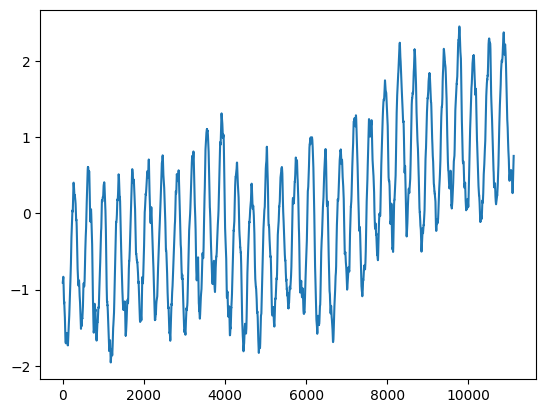

In [4]:

# Directly load the adt data from the file

adt_data = np.load("/content/drive/MyDrive/ECEN250/Lab11/adt_data.npy")

adt_normalized = (adt_data - np.mean(adt_data)) / np.std(adt_data)

train_size = int(0.8 * len(adt_normalized))
val_size = int(0.1 * len(adt_normalized))
test_size = len(adt_normalized) - train_size - val_size

adt_train = adt_normalized[:train_size]
adt_val = adt_normalized[train_size:train_size+val_size]
adt_test = adt_normalized[train_size+val_size:]

plt.plot(adt_normalized)

**Question:**
Insert code to get the size of the adt data.
Suppose the data is measured daily, how many years of data it could contain?

In [5]:
data_size = len(adt_data)
print(f"Size of adt_data: {data_size} data points")

# Assuming daily measurements, calculate the number of years
years_of_data = data_size / 365.25 # Using 365.25 for a more accurate average year length
print(f"This data contains approximately {years_of_data:.2f} years of data")

Size of adt_data: 11115 data points
This data contains approximately 30.43 years of data


We define a custom dataset class (SeaLevelDataset) that inherits from `torch.utils.data.Dataset`.  

Each data sample consists of:
- Input (x): A sequence of the past 30 days of sea level data.
- Target (y): The sea level value of the next day, which we aim to predict.

`seq_length` specifies that each input sample uses 30 consecutive data points (past 30 days) to predict the next value.

In [6]:
import torch
from torch.utils.data import Dataset, DataLoader

class SeaLevelDataset(Dataset):
    def __init__(self, data, seq_length):
        self.data = data
        self.seq_length = seq_length

    def __len__(self):
        # The length of the dataset is reduced by seq_length
        return len(self.data) - self.seq_length

    def __getitem__(self, index):
        # Get the input sequence and the next value as the target
        x = self.data[index:index + self.seq_length]
        y = self.data[index + self.seq_length]
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)


**Question:**

Function `__len__` returns the length of the dataset.  
Why is the length equal to `len(self.data) - self.seq_length`?

ANSWER:
because you also need to account for the length of the starting sequence

Now we create the train/val/test datasets.   



In [7]:
from torch.utils.data import random_split

seq_length = 30

train_dataset = SeaLevelDataset(adt_train, seq_length)
val_dataset = SeaLevelDataset(adt_val, seq_length)
test_dataset = SeaLevelDataset(adt_test, seq_length)

# Create DataLoaders
batch_size = 16  # You can adjust this
loader_train = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
loader_val = DataLoader(val_dataset, batch_size=batch_size, drop_last=True)
loader_test = DataLoader(test_dataset, batch_size=batch_size, drop_last=True)


In [8]:
# Example: Iterate through the training DataLoader
for x_batch, y_batch in loader_train:
    print(f"Input batch shape: {x_batch.shape}")  # Should be (batch_size, seq_length)
    print(f"Target batch shape: {y_batch.shape}")  # Should be (batch_size,)
    break


Input batch shape: torch.Size([16, 30])
Target batch shape: torch.Size([16])


Now we define a simple Recurrent Neural Network (RNN) for predicting the next sea level value based on the previous 30 days.

In [9]:
class SimpleRNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super(SimpleRNN, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x, hidden):
        out, hidden = self.rnn(x, hidden)
        out = self.fc(out[:, -1, :])  # Use the last time step's output
        return out, hidden

    def init_hidden(self, batch_size):
        return torch.zeros(self.num_layers, batch_size, self.hidden_size)

# Hyperparameters
input_size = 1
hidden_size = 10
num_layers = 2
output_size = 1
learning_rate = 0.001
num_epochs = 10

# Initialize the model, loss function, and optimizer
model = SimpleRNN(input_size, hidden_size, num_layers, output_size)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)


Model Training:

**Question:**
Modify the code below to calculate train_losses and val_losses.  

In [10]:
def train_model(model, loader_train, loader_val, num_epochs):
    train_losses = []
    val_losses = []

    for epoch in range(num_epochs):
        model.train()
        # Initialize hidden state for training
        hidden_train = model.init_hidden(batch_size)
        epoch_train_loss = 0

        for x_batch, y_batch in loader_train:
            x_batch = x_batch.unsqueeze(-1)
            y_batch = y_batch.unsqueeze(-1)

            # Detach hidden state to prevent backprop through entire history
            hidden_train = hidden_train.detach()
            optimizer.zero_grad()

            outputs, hidden_train = model(x_batch, hidden_train)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            epoch_train_loss += loss.item()

        avg_epoch_train_loss = epoch_train_loss / len(loader_train)
        train_losses.append(avg_epoch_train_loss)

        # Validation
        model.eval()
        # Initialize hidden state for validation
        hidden_val = model.init_hidden(batch_size)
        epoch_val_loss = 0

        with torch.no_grad():
            for x_batch, y_batch in loader_val:
                x_batch = x_batch.unsqueeze(-1)
                y_batch = y_batch.unsqueeze(-1)

                outputs, hidden_val = model(x_batch, hidden_val)
                loss = criterion(outputs, y_batch)
                epoch_val_loss += loss.item()

        avg_epoch_val_loss = epoch_val_loss / len(loader_val)
        val_losses.append(avg_epoch_val_loss)

        print(f"Epoch [{epoch + 1}/{num_epochs}], Train Loss: {train_losses[-1]:.4f}, Val Loss: {val_losses[-1]:.4f}")

    return train_losses, val_losses

In [11]:
# Train the model
print("loader_train", len(loader_train))
train_losses, val_losses = train_model(model, loader_train, loader_val, num_epochs)

loader_train 553
Epoch [1/10], Train Loss: 0.0741, Val Loss: 0.0093
Epoch [2/10], Train Loss: 0.0021, Val Loss: 0.0037
Epoch [3/10], Train Loss: 0.0013, Val Loss: 0.0024
Epoch [4/10], Train Loss: 0.0008, Val Loss: 0.0014
Epoch [5/10], Train Loss: 0.0005, Val Loss: 0.0011
Epoch [6/10], Train Loss: 0.0003, Val Loss: 0.0008
Epoch [7/10], Train Loss: 0.0003, Val Loss: 0.0005
Epoch [8/10], Train Loss: 0.0002, Val Loss: 0.0007
Epoch [9/10], Train Loss: 0.0002, Val Loss: 0.0004
Epoch [10/10], Train Loss: 0.0002, Val Loss: 0.0003


**Question:**
Plot the training loss and validation loss in the same figure.

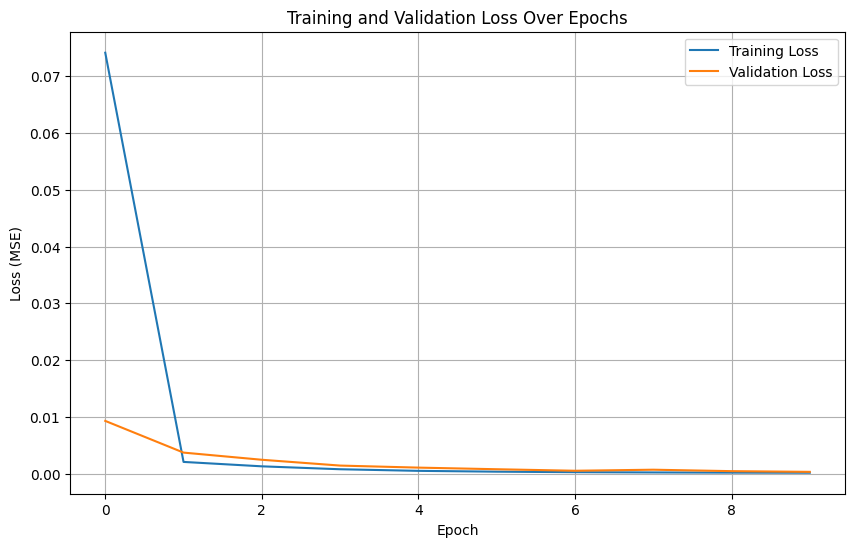

In [12]:
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

Now we evaluate the model with the test set:

In [13]:
def evaluate_model(model, loader_test):
    model.eval()
    hidden = model.init_hidden(batch_size)
    test_loss = 0
    predictions = []
    true_values = []

    with torch.no_grad():
        for x_batch, y_batch in loader_test:
            x_batch = x_batch.unsqueeze(-1)
            y_batch = y_batch.unsqueeze(-1)

            outputs, hidden = model(x_batch, hidden)
            loss = criterion(outputs, y_batch)
            test_loss += loss.item()

            predictions.extend(outputs.squeeze().tolist())
            true_values.extend(y_batch.squeeze().tolist())

    avg_test_loss = test_loss / len(loader_test)
    print(f"Test Loss: {avg_test_loss:.4f}")

    return predictions, true_values

# Evaluate the model on the test set
predictions, true_values = evaluate_model(model, loader_test)


Test Loss: 0.0003


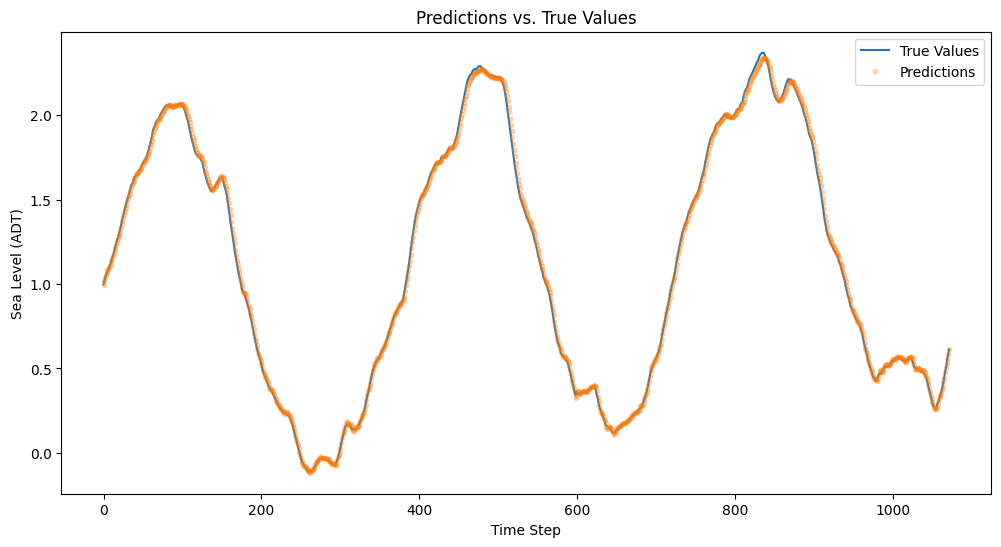

In [14]:
def plot_predictions(predictions, true_values):
    plt.figure(figsize=(12, 6))
    plt.plot(true_values[:], label='True Values')
    plt.plot(predictions[:], label='Predictions', alpha=0.3, marker='.', linestyle='')
    plt.xlabel('Time Step')
    plt.ylabel('Sea Level (ADT)')
    plt.legend()
    plt.title('Predictions vs. True Values')
    plt.show()

# Plot the predictions
plot_predictions(predictions, true_values)

# Part 2: Predicting the Next 2 Days of Sea Level

In this part of the lab, you will extend your model to predict the next two days of sea level data based on the past 30 days of data.  

This task requires adjusting the model to output two values (the sea level for the next two days) instead of just one, which will test your understanding of how sequence-based models like RNNs can handle multi-step prediction.

## Part 2.1: Creating the Dataset

- You need to modify the dataset class below to handle sequences of 30 past data points as the input and 2 future data points as the output.
- The `input_seq_length` should be set to 30 (representing the past 30 days), and the `output_seq_length` should be set to 2 (representing the next 2 days).
- After implementing the dataset class, you will create data loaders for training, validation, and testing.

In [15]:
class SeaLevelDataset(Dataset):
    def __init__(self, data, input_seq_length, output_seq_length):
        self.data = data
        self.input_seq_length = input_seq_length
        self.output_seq_length = output_seq_length

    def __len__(self):
        # Returns the number of samples in the dataset
        # The length is reduced by the input sequence length and the output sequence length minus 1
        return len(self.data) - self.input_seq_length - self.output_seq_length + 1

    def __getitem__(self, index):
        '''
        The __getitem__ method in the Dataset class should return two things:
        x: The input sequence of 30 days.
        y: The target sequence, which is the next two days.
        x and y should both be torch tensors.
        '''
        x = self.data[index : index + self.input_seq_length]
        y = self.data[index + self.input_seq_length : index + self.input_seq_length + self.output_seq_length]
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)


# Initialize datasets and data loaders
input_seq_length = 30
output_seq_length = 2
batch_size = 64

# Create datasets
train_dataset_part2 = SeaLevelDataset(adt_train, input_seq_length, output_seq_length)
val_dataset_part2 = SeaLevelDataset(adt_val, input_seq_length, output_seq_length)
test_dataset_part2 = SeaLevelDataset(adt_test, input_seq_length, output_seq_length)

# Create DataLoaders
loader_train_part2 = DataLoader(train_dataset_part2, batch_size=batch_size, shuffle=True, drop_last=True)
loader_val_part2 = DataLoader(val_dataset_part2, batch_size=batch_size, drop_last=True)
loader_test_part2 = DataLoader(test_dataset_part2, batch_size=batch_size, drop_last=True)

Below we provide the Updated RNN model.  
We maintain the `hidden_size`, `num_layers`, and `output_seq_length` parameters to control the depth and the output sequence length (which is now 2 for a 2-day prediction).


In [16]:
# Updated SimpleRNN model
class SimpleRNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_seq_length):
        super(SimpleRNN, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.output_seq_length = output_seq_length
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x, hidden):
        out, hidden = self.rnn(x, hidden)
        predictions = self.fc(out[:, -self.output_seq_length:, :])
        predictions = predictions.squeeze(-1)
        return predictions, hidden

    def init_hidden(self, batch_size):
        return torch.zeros(self.num_layers, batch_size, self.hidden_size)

# Hyperparameters
input_size = 1
hidden_size = 30
num_layers = 2

model = SimpleRNN(input_size, hidden_size, num_layers, output_seq_length)

**Question:**  
Insert code below, to train the model.  
Print and plot the training loss and validation loss per epoch.

Starting training for Part 2...
Epoch [1/20], Train Loss: 0.7919, Val Loss: 0.8639
Epoch [2/20], Train Loss: 0.1162, Val Loss: 0.1203
Epoch [3/20], Train Loss: 0.0339, Val Loss: 0.0811
Epoch [4/20], Train Loss: 0.0249, Val Loss: 0.0595
Epoch [5/20], Train Loss: 0.0195, Val Loss: 0.0454
Epoch [6/20], Train Loss: 0.0168, Val Loss: 0.0362
Epoch [7/20], Train Loss: 0.0143, Val Loss: 0.0286
Epoch [8/20], Train Loss: 0.0128, Val Loss: 0.0235
Epoch [9/20], Train Loss: 0.0113, Val Loss: 0.0183
Epoch [10/20], Train Loss: 0.0102, Val Loss: 0.0145
Epoch [11/20], Train Loss: 0.0090, Val Loss: 0.0115
Epoch [12/20], Train Loss: 0.0082, Val Loss: 0.0083
Epoch [13/20], Train Loss: 0.0075, Val Loss: 0.0075
Epoch [14/20], Train Loss: 0.0070, Val Loss: 0.0061
Epoch [15/20], Train Loss: 0.0066, Val Loss: 0.0060
Epoch [16/20], Train Loss: 0.0063, Val Loss: 0.0052
Epoch [17/20], Train Loss: 0.0059, Val Loss: 0.0051
Epoch [18/20], Train Loss: 0.0058, Val Loss: 0.0048
Epoch [19/20], Train Loss: 0.0054, Val Lo

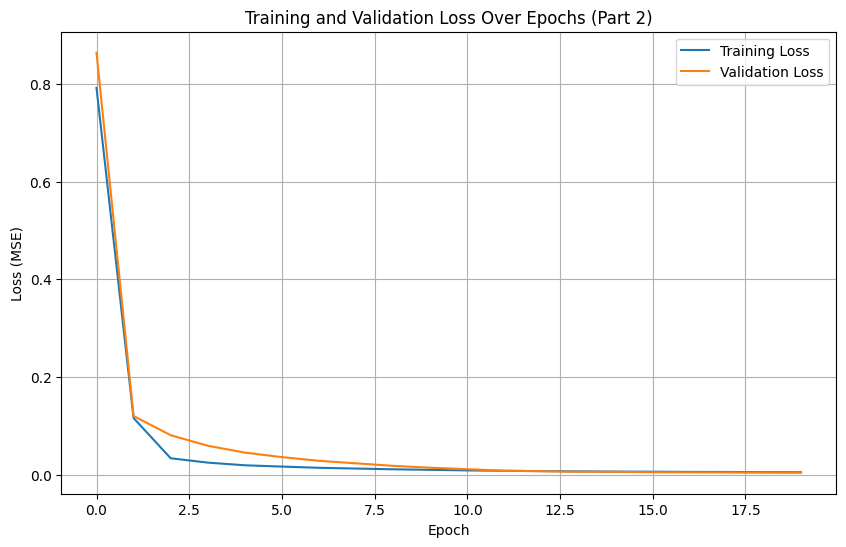

In [17]:
## You can adjust the hyperparameters below if needed.
learning_rate = 0.0001
num_epochs = 20

# Initialize the loss function and optimizer for the new model
criterion_part2 = nn.MSELoss()
optimizer_part2 = optim.Adam(model.parameters(), lr=learning_rate)

def train_model_part2(model, loader_train, loader_val, num_epochs, criterion, optimizer):
    train_losses = []
    val_losses = []

    for epoch in range(num_epochs):
        model.train()
        hidden_train = model.init_hidden(batch_size)
        epoch_train_loss = 0

        for x_batch, y_batch in loader_train:
            x_batch = x_batch.unsqueeze(-1) # Add feature dimension

            hidden_train = hidden_train.detach()
            optimizer.zero_grad()

            outputs, hidden_train = model(x_batch, hidden_train)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            epoch_train_loss += loss.item()

        avg_epoch_train_loss = epoch_train_loss / len(loader_train)
        train_losses.append(avg_epoch_train_loss)

        model.eval()
        hidden_val = model.init_hidden(batch_size)
        epoch_val_loss = 0

        with torch.no_grad():
            for x_batch, y_batch in loader_val:
                x_batch = x_batch.unsqueeze(-1) # Add feature dimension

                outputs, hidden_val = model(x_batch, hidden_val)
                loss = criterion(outputs, y_batch)
                epoch_val_loss += loss.item()

        avg_epoch_val_loss = epoch_val_loss / len(loader_val)
        val_losses.append(avg_epoch_val_loss)

        print(f"Epoch [{epoch + 1}/{num_epochs}], Train Loss: {train_losses[-1]:.4f}, Val Loss: {val_losses[-1]:.4f}")

    return train_losses, val_losses

# Train the model for Part 2
print("Starting training for Part 2...")
train_losses_part2, val_losses_part2 = train_model_part2(model, loader_train_part2, loader_val_part2, num_epochs, criterion_part2, optimizer_part2)

# Plot the training and validation loss
plt.figure(figsize=(10, 6))
plt.plot(train_losses_part2, label='Training Loss')
plt.plot(val_losses_part2, label='Validation Loss')
plt.title('Training and Validation Loss Over Epochs (Part 2)')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

**Question:**  
Insert code below to evaluate the model on the test set and plot the predictions.

Test Loss (Part 2): 0.0048


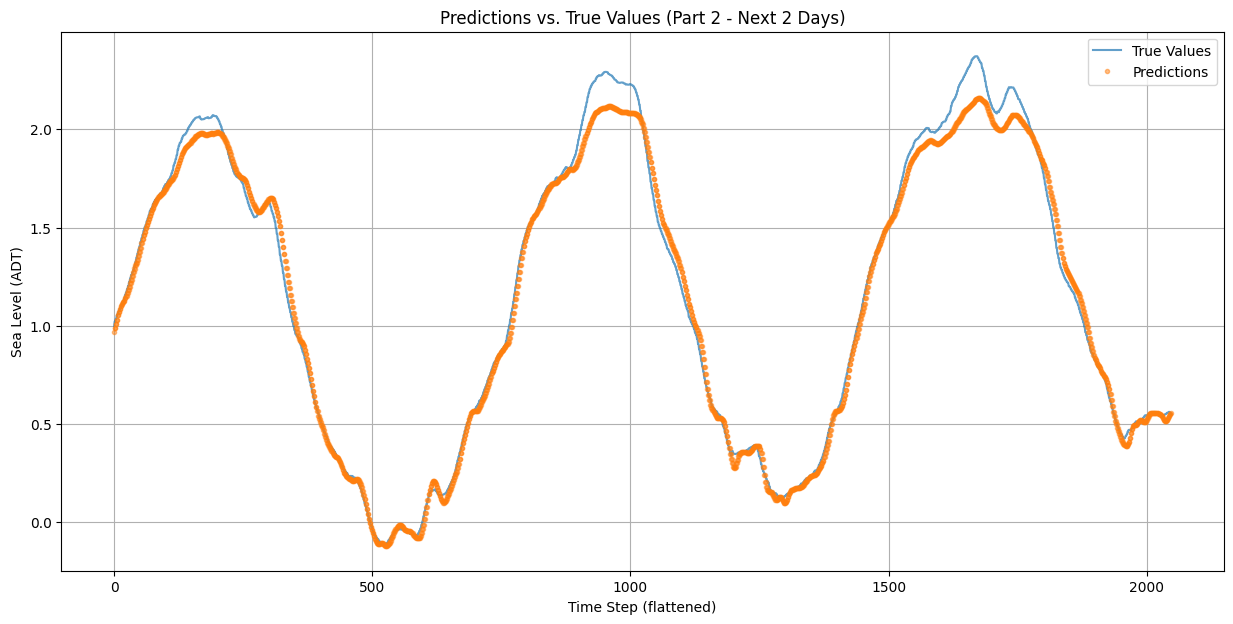

In [18]:
def evaluate_model_part2(model, loader_test, criterion):
    model.eval()
    hidden = model.init_hidden(batch_size)
    test_loss = 0
    predictions = []
    true_values = []

    with torch.no_grad():
        for x_batch, y_batch in loader_test:
            x_batch = x_batch.unsqueeze(-1)

            outputs, hidden = model(x_batch, hidden)
            loss = criterion(outputs, y_batch)
            test_loss += loss.item()

            # Flatten predictions and true values for plotting
            predictions.extend(outputs.reshape(-1).tolist())
            true_values.extend(y_batch.reshape(-1).tolist())

    avg_test_loss = test_loss / len(loader_test)
    print(f"Test Loss (Part 2): {avg_test_loss:.4f}")

    return predictions, true_values

def plot_predictions_part2(predictions, true_values):
    plt.figure(figsize=(15, 7))
    plt.plot(true_values, label='True Values', alpha=0.7)
    # Plot predictions as markers to distinguish from true values
    plt.plot(predictions, 'o', label='Predictions', markersize=3, alpha=0.5)
    plt.xlabel('Time Step (flattened)')
    plt.ylabel('Sea Level (ADT)')
    plt.legend()
    plt.title('Predictions vs. True Values (Part 2 - Next 2 Days)')
    plt.grid(True)
    plt.show()

# Evaluate the model on the test set for Part 2
predictions_part2, true_values_part2 = evaluate_model_part2(model, loader_test_part2, criterion_part2)

# Plot the predictions for Part 2
plot_predictions_part2(predictions_part2, true_values_part2)

Lab 11 is now complete.  Make sure all cells are visible and have been run (rerun if necessary).

The code below converts the ipynb file to PDF, and saves it to where this .ipynb file is.

In [ ]:
NOTEBOOK_PATH = # Enter here, the path to your notebook file, e.g. "/content/drive/MyDrive/ECEN250/ECEN250_Lab11.ipynb". Do not change the lines below, and make sure you do not have multiple notebooks with the same path
! pip install -U nbconvert playwright
! playwright install-deps
! jupyter nbconvert --to webpdf --allow-chromium-download "$NOTEBOOK_PATH"

Download your notebook as an .ipynb file, then upload it along with the PDF file (saved in the same Google Drive folder as this notebook) to Canvas for Lab 11. Make sure that the PDF file matches your .ipynb file.